In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ── 1. Load & clean ──────────────────────────────────────────────────────────
file_path = '/Users/johnscanlan/Documents/Farm/MartIndex/March24.xlsx'
df = pd.read_excel(file_path)
df = df.drop('Lot', axis=1)
df = df[df['Breed'].apply(lambda x: isinstance(x, str))]

# Keep a copy with original string labels for plotting
df_plot = df.copy()

# ── 2. Encode categoricals ────────────────────────────────────────────────────
le_breed    = LabelEncoder()
le_location = LabelEncoder()
le_sex      = LabelEncoder()

df['Breed']    = le_breed.fit_transform(df['Breed'])
df['Location'] = le_location.fit_transform(df['Location'])
df['Sex']      = le_sex.fit_transform(df['Sex'])

# ── 3. Train model ────────────────────────────────────────────────────────────
X = df[['Weight', 'Breed', 'Sex', 'Location']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R² Score : {r2:.4f}')
print(f'RMSE     : {rmse:.2f}')

R² Score : 0.9044
RMSE     : 184.90


In [2]:
# ── 4. Predict: 330 kg AAX male ───────────────────────────────────────────────
# Resolve breed "AAX" – handle case where it may not be in training data
if 'AAX' in le_breed.classes_:
    aax_enc = le_breed.transform(['AAX'])[0]
else:
    raise ValueError("Breed 'AAX' not found in data. Check spelling.")

male_label = None
for label in le_sex.classes_:
    if label.strip().upper() in ('M', 'MALE', 'BULL', 'BULLOCK', 'STEER'):
        male_label = label
        break
if male_label is None:
    raise ValueError(f"Could not find a male category. Available: {list(le_sex.classes_)}")

male_enc = le_sex.transform([male_label])[0]

# Use median location as a neutral baseline
median_location = int(np.median(df['Location']))

pred_input = pd.DataFrame({
    'Weight':   [330],
    'Breed':    [aax_enc],
    'Sex':      [male_enc],
    'Location': [median_location],
})

predicted_price = model.predict(pred_input)[0]
print(f'\nPredicted price for 330 kg AAX male: €{predicted_price:,.2f}')


Predicted price for 330 kg AAX male: €1,427.02



Plot saved → /Users/johnscanlan/Documents/Farm/MartIndex/mart_analysis.png


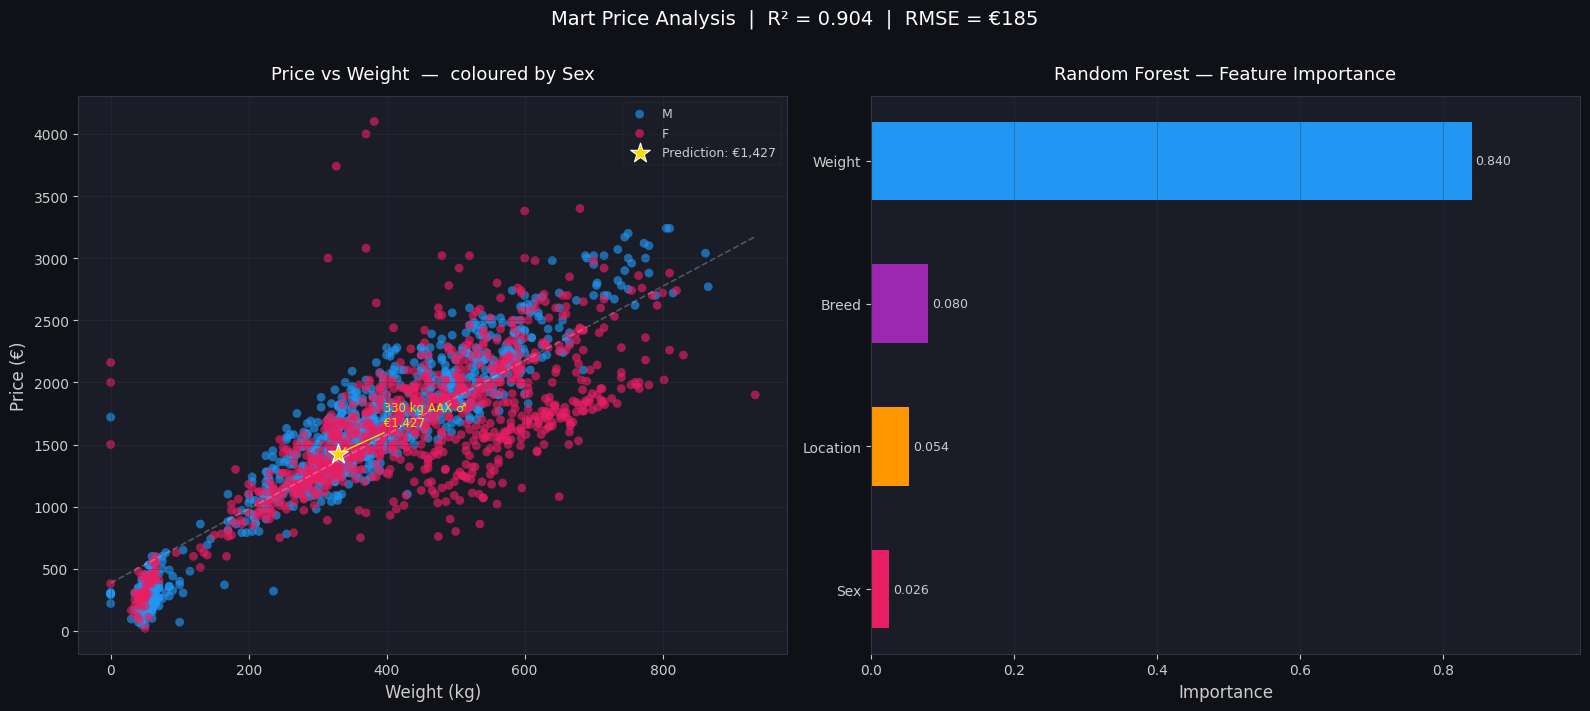

In [3]:
# ── 5. Visualisation ──────────────────────────────────────────────────────────
sex_categories = df_plot['Sex'].unique()
palette = {
    cat: col for cat, col in zip(
        sex_categories,
        ['#2196F3', '#E91E63', '#FF9800', '#4CAF50']
    )
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#cccccc')
    ax.xaxis.label.set_color('#cccccc')
    ax.yaxis.label.set_color('#cccccc')
    ax.title.set_color('#ffffff')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

# ── Plot 1: Price vs Weight coloured by Sex ───────────────────────────────────
ax1 = axes[0]
for sex_val in sex_categories:
    mask = df_plot['Sex'] == sex_val
    ax1.scatter(
        df_plot.loc[mask, 'Weight'],
        df_plot.loc[mask, 'Price'],
        c=palette[sex_val],
        alpha=0.65,
        s=40,
        edgecolors='none',
        label=str(sex_val),
    )

# Highlight prediction point
ax1.scatter(
    330, predicted_price,
    c='#FFD700', s=220, zorder=5,
    marker='*', edgecolors='white', linewidths=0.8,
    label=f'Prediction: €{predicted_price:,.0f}'
)

# Trend line (all animals)
z = np.polyfit(df_plot['Weight'], df_plot['Price'], 1)
p = np.poly1d(z)
w_range = np.linspace(df_plot['Weight'].min(), df_plot['Weight'].max(), 200)
ax1.plot(w_range, p(w_range), '--', color='#ffffff', alpha=0.25, lw=1.2)

ax1.set_xlabel('Weight (kg)', fontsize=12)
ax1.set_ylabel('Price (€)', fontsize=12)
ax1.set_title('Price vs Weight  —  coloured by Sex', fontsize=13, pad=12)
ax1.legend(
    framealpha=0.2, facecolor='#1a1d27', edgecolor='#444',
    labelcolor='#cccccc', fontsize=9
)
ax1.grid(True, color='#333344', linewidth=0.5, alpha=0.5)

# Annotate prediction
ax1.annotate(
    f' 330 kg AAX ♂\n €{predicted_price:,.0f}',
    xy=(330, predicted_price),
    xytext=(30, 20), textcoords='offset points',
    fontsize=8.5, color='#FFD700',
    arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1),
)

# ── Plot 2: Feature Importance ────────────────────────────────────────────────
ax2 = axes[1]
feature_names = ['Weight', 'Breed', 'Sex', 'Location']
importances = model.feature_importances_
order = np.argsort(importances)
bar_colors = ['#2196F3', '#9C27B0', '#E91E63', '#FF9800']

bars = ax2.barh(
    [feature_names[i] for i in order],
    importances[order],
    color=[bar_colors[i] for i in order],
    edgecolor='none',
    height=0.55,
)

for bar, val in zip(bars, importances[order]):
    ax2.text(
        val + 0.005, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', ha='left',
        color='#cccccc', fontsize=9
    )

ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Random Forest — Feature Importance', fontsize=13, pad=12)
ax2.grid(True, axis='x', color='#333344', linewidth=0.5, alpha=0.5)
ax2.set_xlim(0, max(importances) * 1.18)

# ── Overall title ─────────────────────────────────────────────────────────────
fig.suptitle(
    f'Mart Price Analysis  |  R² = {r2:.3f}  |  RMSE = €{rmse:.0f}',
    fontsize=14, color='#ffffff', y=1.01
)

plt.tight_layout()
output_path = '/Users/johnscanlan/Documents/Farm/MartIndex/mart_analysis.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'\nPlot saved → {output_path}')
plt.show()